### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [19]:
import pandas as pd

In [20]:
drugs = pd.read_csv (r'data\drugLibTrain_raw.tsv', sep="\t")

In [21]:
drugs.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


In [22]:
drugs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
dtypes: int64(2), object(7)
memory usage: 218.6+ KB


### Descriptive Analysis

Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categóricas con pocas categorías (menos de 10)

In [23]:
# las columnas categoricas son tipo object y las numéricas int64
col_cat = drugs.select_dtypes (include='object')
col_num = drugs.select_dtypes(include='int64')

In [24]:
# Que tengan menos de 10 categorías
columnas = [] # para almacenar los nombres de las que cumplan el requisito
for col in col_cat:
    if col_cat[col].nunique() < 10:
        columnas.append (col) 
col_cat = col_cat [columnas]
col_cat
# Entien

,effectiveness,sideEffects
0,Highly Effective,Mild Side Effects
1,Highly Effective,Severe Side Effects
2,Highly Effective,No Side Effects
3,Marginally Effective,Mild Side Effects
4,Marginally Effective,Severe Side Effects
...,...,...
3102,Highly Effective,Mild Side Effects
3103,Ineffective,Extremely Severe Side Effects
3104,Marginally Effective,Moderate Side Effects
3105,Considerably Effective,Mild Side Effects


In [25]:
drugs_new = pd.concat ([col_num, col_cat], axis=1 )

#### Transforma las columnas categóricas

Transforma las columnas categoricas a numericas mediante dummies

In [27]:
drugs_new ['sideEffects'].unique()

array(['Mild Side Effects', 'Severe Side Effects', 'No Side Effects',
       'Extremely Severe Side Effects', 'Moderate Side Effects'],
      dtype=object)

In [28]:
# Definimos los pesos para las columnas
pesos_effectiveness= {
    'Ineffective': 1,
    'Marginally Effective': 2,
    'Moderately Effective': 3,
    'Considerably Effective':4,
    'Highly Effective': 5
}

pesos_sideEffects= {
    'No Side Effects': 1,
    'Mild Side Effects': 2, 
    'Moderate Side Effects': 3,
    'Severe Side Effects': 4, 
    'Extremely Severe Side Effects': 5 
    
}
# Aplicamos el mapeo a las columnas
drugs_new['effectiveness'] = drugs_new['effectiveness'].map(pesos_effectiveness)
drugs_new['sideEffects'] = drugs_new['sideEffects'].map(pesos_sideEffects)

In [29]:
drugs_new

,Unnamed: 0,rating,effectiveness,sideEffects
0,2202,4,5,2
1,3117,1,5,4
2,1146,10,5,1
3,3947,3,2,2
4,1951,2,2,4
...,...,...,...,...
3102,1039,10,5,2
3103,3281,1,1,5
3104,1664,2,2,3
3105,2621,8,4,2


In [31]:
# Unnamed:0 es el ID, quitamos y dejamos lo demás como features (X)
X = drugs_new.drop ('Unnamed: 0', axis=1)
X

,rating,effectiveness,sideEffects
0,4,5,2
1,1,5,4
2,10,5,1
3,3,2,2
4,2,2,4
...,...,...,...
3102,10,5,2
3103,1,1,5
3104,2,2,3
3105,8,4,2


#### Evalua cual es la mejor K

Utiliza silhouette_score para evaluar cual es la mejor K.

#### Genera el K Means 

In [35]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#Voy a generar varios kmeans con ks entre 2 y 30. 

silhouette_scores = []
K_range = range(2, 15)  

# Genero, entreno y hago predicciones con cada k. 
# Guardo su silhouette score 
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"K={k} → Silhouette Score: {score:.4f}")


K=2 → Silhouette Score: 0.6191
K=3 → Silhouette Score: 0.4542
K=4 → Silhouette Score: 0.4167
K=5 → Silhouette Score: 0.4152
K=6 → Silhouette Score: 0.4078
K=7 → Silhouette Score: 0.4045
K=8 → Silhouette Score: 0.3887
K=9 → Silhouette Score: 0.4139
K=10 → Silhouette Score: 0.4074
K=11 → Silhouette Score: 0.4310
K=12 → Silhouette Score: 0.4191
K=13 → Silhouette Score: 0.4598
K=14 → Silhouette Score: 0.4448


In [36]:

# El mejor K
best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nMejor K: {best_k}")



Mejor K: 2


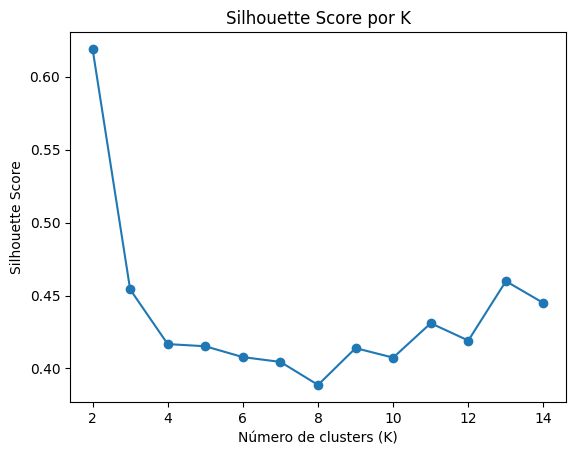

In [37]:

# Visualización
plt.plot(list(K_range), silhouette_scores, marker='o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por K')
plt.show()




Comprueba los resultados y muestra en un pie plot la distribución de los distintos clusters.

Distribución de clusters:
cluster
0    2284
1     823
Name: count, dtype: int64

Centroides (en escala normalizada):
[[8.56961471 4.42250438 1.88047285]
 [2.66707169 2.58444714 3.48238153]]

Media de cada variable por cluster:
         rating  effectiveness  sideEffects
cluster                                    
0          8.57           4.42         1.88
1          2.67           2.58         3.48


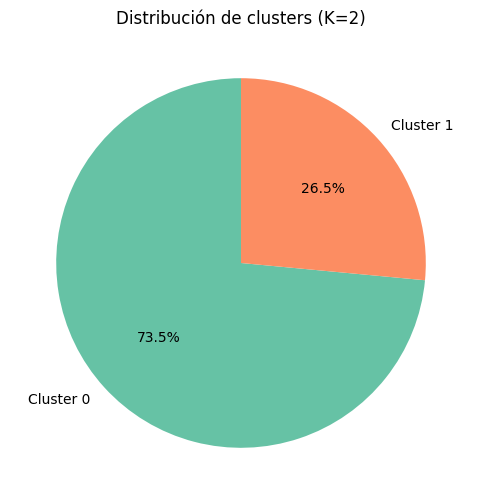

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Entrenar con el K elegido
best_k = 2
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
X['cluster'] = kmeans.fit_predict(X)  

# --- Comprobación de resultados ---
print("Distribución de clusters:")
print(X['cluster'].value_counts())
print("\nCentroides (en escala normalizada):")
print(kmeans.cluster_centers_)
print("\nMedia de cada variable por cluster:")
print(X.groupby('cluster')[['rating', 'effectiveness', 'sideEffects']].mean().round(2))

# --- Pie chart ---
cluster_counts = X['cluster'].value_counts().sort_index()
labels = [f'Cluster {i}' for i in cluster_counts.index]

plt.figure(figsize=(6, 6))
plt.pie(
    cluster_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set2.colors[:best_k]
)
plt.title(f'Distribución de clusters (K={best_k})')
plt.show()

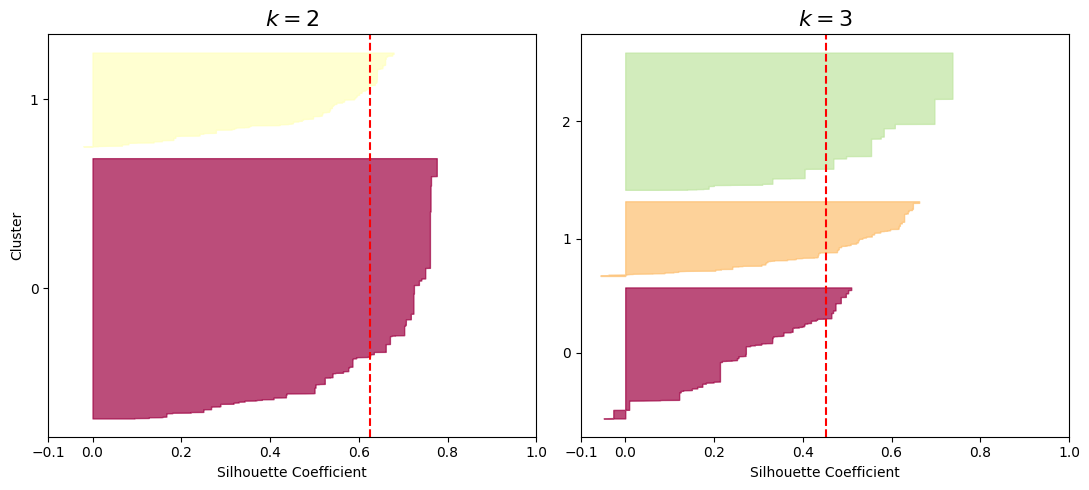

In [40]:
# Adapto la gráfica que vimos en  clase con las clases y la media de silohuette para ver si se interpreta mejor
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter

import numpy as np
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans

# Entrenar modelos para k=2 y k=3
kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X)
kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X)

kmeans_per_k = [kmeans_k2, kmeans_k3]
k_values = [2, 3]

# Calcular silhouette score medio para cada k (la línea roja)
silhouette_scores = [silhouette_score(X, m.labels_) for m in kmeans_per_k]

plt.figure(figsize=(11, 5))  

for idx, k in enumerate(k_values):
    plt.subplot(1, 2, idx + 1)  # 1 fila, 2 columnas

    y_pred = kmeans_per_k[idx].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    # Etiqueta Y solo en el subplot izquierdo
    if idx == 0:
        plt.ylabel("Cluster")

    # Etiqueta X y ticks en ambos subplots
    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    # Línea roja con el score medio
    plt.axvline(x=silhouette_scores[idx], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.tight_layout()
plt.savefig("silhouette_analysis_k2_k3.png", dpi=150, bbox_inches="tight")
plt.show()

Parece que k=2 es mejor. Con k=3 tiene más puntos mal clasificados en los clusters 1 y 0.
Tampoco k=2 parece muy muy fino. En el cluster 1 hay pocos valores por encima de la media y tiene puntos mal clasficados también
